In [16]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Population Learning Curves

This notebook tracks how quickly each policy reduces posterior uncertainty across a synthetic user population. Unlike the single-user geometry in notebook 08, the curves here average D-error after each answered question across many episodes.

D-error is `det(Sigma_k)^(1/d)`, the geometric mean posterior variance. Lower values mean a tighter posterior belief.


In [17]:

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.append(str(PROJECT_ROOT))
sys.path.append(str(PROJECT_ROOT / "notebooks"))

from _sweep_helpers import POLICY_STYLE
from src.belief import BeliefState
from src.metrics import aggregate_policy_metrics, mean_estimation_error
from src.plots import PALETTE, apply_notebook_style, style_ax
from src.policies import PolicyName, make_sensitive_constant_stay_prob
from src.simulate import EpisodeResult, simulate_population
from src.synthetic import generate_user_population, synthetic_item_bank

apply_notebook_style()
print(f"Using project root: {PROJECT_ROOT}")


Using project root: c:\Users\49160\Adaptive-Onboarding


## Configuration

These defaults mirror the policy-comparison experiments, but the notebook keeps the full per-step trajectories in memory so we can plot learning curves. Set `SENSITIVITY_ASSIGNMENT = "high_trait_tail"` to use the targeted sensitive-item construction.

`myopic_exact` is opt-in because it is much slower on population runs; set `INCLUDE_MYOPIC = True` when you want the complete policy set.


In [21]:
DIM = 2
N_ITEMS = 30
N_CATEGORIES = 4
SENSITIVE_FRACTION = 0.30
SENSITIVITY_ASSIGNMENT = "high_trait_tail"  # "random", "axis_aligned", or "high_trait_tail"
SENSITIVE_AXES =[ 0, 1]  # both axes          # None defaults to the final axis for high_trait_tail
P_DROPOUT = 0.10
N_USERS = 500
HORIZON = 8
INCLUDE_MYOPIC = True

SEED_BANK = 0
SEED_POP = 1
SEED_SIM = 2

POLICIES: list[PolicyName] = [
    "fixed",
    "random",
    "surrogate_unweighted",
    "surrogate_weighted",
]
if INCLUDE_MYOPIC:
    POLICIES.insert(2, "myopic_exact")


## Simulate Policies

All policies share the same item bank, user population, prior, dropout model, and horizon. Each policy receives a reproducible simulation stream derived from `SEED_SIM` and the policy index.


In [22]:
item_bank = synthetic_item_bank(
    n_items=N_ITEMS,
    dim=DIM,
    n_categories=N_CATEGORIES,
    sensitive_fraction=SENSITIVE_FRACTION,
    sensitivity_assignment=SENSITIVITY_ASSIGNMENT,
    sensitive_axes=SENSITIVE_AXES,
    rng_seed=SEED_BANK,
    vary_sensitivity_levels=False,
)

theta_trues = generate_user_population(n_users=N_USERS, dim=DIM, rng_seed=SEED_POP)
stay_prob_fn = make_sensitive_constant_stay_prob(
    p_stay_sensitive=1.0 - P_DROPOUT,
    p_stay_normal=1.0,
)
prior = BeliefState(mu=np.zeros(DIM), Sigma=np.eye(DIM))

policy_results: dict[str, list[EpisodeResult]] = {}

for policy_index, policy in enumerate(POLICIES):
    print(f"simulating {policy:22s} ...", end=" ", flush=True)
    results = simulate_population(
        theta_trues=theta_trues,
        prior_belief=prior,
        item_bank=item_bank,
        strategy=policy,
        horizon=HORIZON,
        stay_prob_fn=stay_prob_fn,
        rng=np.random.default_rng([SEED_SIM, policy_index]),
    )
    policy_results[policy] = results
    n_drop = sum(result.terminated_by_dropout for result in results)
    print(f"dropout {n_drop}/{N_USERS} = {n_drop / N_USERS:.1%}")

print("done")


simulating fixed                  ... dropout 171/500 = 34.2%
simulating random                 ... dropout 107/500 = 21.4%
simulating myopic_exact           ... dropout 0/500 = 0.0%
simulating surrogate_unweighted   ... dropout 64/500 = 12.8%
simulating surrogate_weighted     ... dropout 0/500 = 0.0%
done


## Summary Table

The final metrics should agree with the corresponding single-condition policy-comparison run, up to RNG-stream differences.


In [23]:
summary_rows = []
for policy, results in policy_results.items():
    metrics = aggregate_policy_metrics(results, policy_name=policy, item_bank=item_bank)
    summary_rows.append({
        "policy": POLICY_STYLE.get(policy, {}).get("label", policy),
        "dropout_rate": metrics.dropout_rate,
        "mean_answered": metrics.mean_n_answered,
        "mean_sensitive_rate": metrics.sensitive_rate,
        "mean_final_d_error": metrics.mean_final_d_error,
        "mean_final_d_error_completed": metrics.mean_final_d_error_completed,
        "mean_estimation_error": mean_estimation_error(results, theta_trues),
    })

summary = pd.DataFrame(summary_rows)
summary


,policy,dropout_rate,mean_answered,mean_sensitive_rate,mean_final_d_error,mean_final_d_error_completed,mean_estimation_error
0,Fixed,0.342,5.698,0.564238,0.478089,0.327788,0.914091
1,Random,0.214,7.094,0.292282,0.303454,0.252177,0.657190
2,Myopic (exact),0.000,8.000,0.000000,0.243433,0.243433,0.615182
3,Surrogate (unweighted),0.128,7.628,0.131253,0.260760,0.245564,0.630792
4,Surrogate (weighted),0.000,8.000,0.000000,0.247177,0.247177,0.639919


## Build Per-Step D-Error Series

`available` averages only over episodes that have reached a given answered-question count without dropout. `carried` pads each episode with its final covariance after dropout, so it treats dropout as stopping the learning process and keeps those users in the denominator through the horizon, the D-error stays the same across episodes where no further question was asked.


In [24]:
def d_error_from_cov(Sigma: np.ndarray) -> float:
    sign, logdet = np.linalg.slogdet(Sigma)
    if sign <= 0:
        raise ValueError("Covariance matrix is not positive definite.")
    return float(np.exp(logdet / Sigma.shape[0]))


def episode_d_error_series(result: EpisodeResult, prior_belief: BeliefState) -> np.ndarray:
    values = [d_error_from_cov(prior_belief.Sigma)]
    for step in result.steps:
        if step.dropped_out:
            break
        values.append(d_error_from_cov(step.belief_Sigma_after))
    return np.array(values, dtype=float)


def aggregate_learning_curve(
    results: list[EpisodeResult],
    prior_belief: BeliefState,
    horizon: int,
    *,
    carry_forward: bool,
) -> pd.DataFrame:
    series = [episode_d_error_series(result, prior_belief) for result in results]
    rows = []
    for answered in range(horizon + 1):
        values = []
        for values_i in series:
            if answered < len(values_i):
                values.append(values_i[answered])
            elif carry_forward:
                values.append(values_i[-1])
        if not values:
            continue
        arr = np.array(values, dtype=float)
        rows.append({
            "answered": answered,
            "mean": float(np.mean(arr)),
            "median": float(np.median(arr)),
            "q25": float(np.quantile(arr, 0.25)),
            "q75": float(np.quantile(arr, 0.75)),
            "n": int(arr.size),
        })
    return pd.DataFrame(rows)


curves = {
    policy: {
        "available": aggregate_learning_curve(results, prior, HORIZON, carry_forward=False),
        "carried": aggregate_learning_curve(results, prior, HORIZON, carry_forward=True),
    }
    for policy, results in policy_results.items()
}


## Learning Curves

The left panel isolates learning speed conditional on still receiving answers. The right panel visualizes `carried`: after dropout, the posterior stops improving and that final D-error is carried forward.


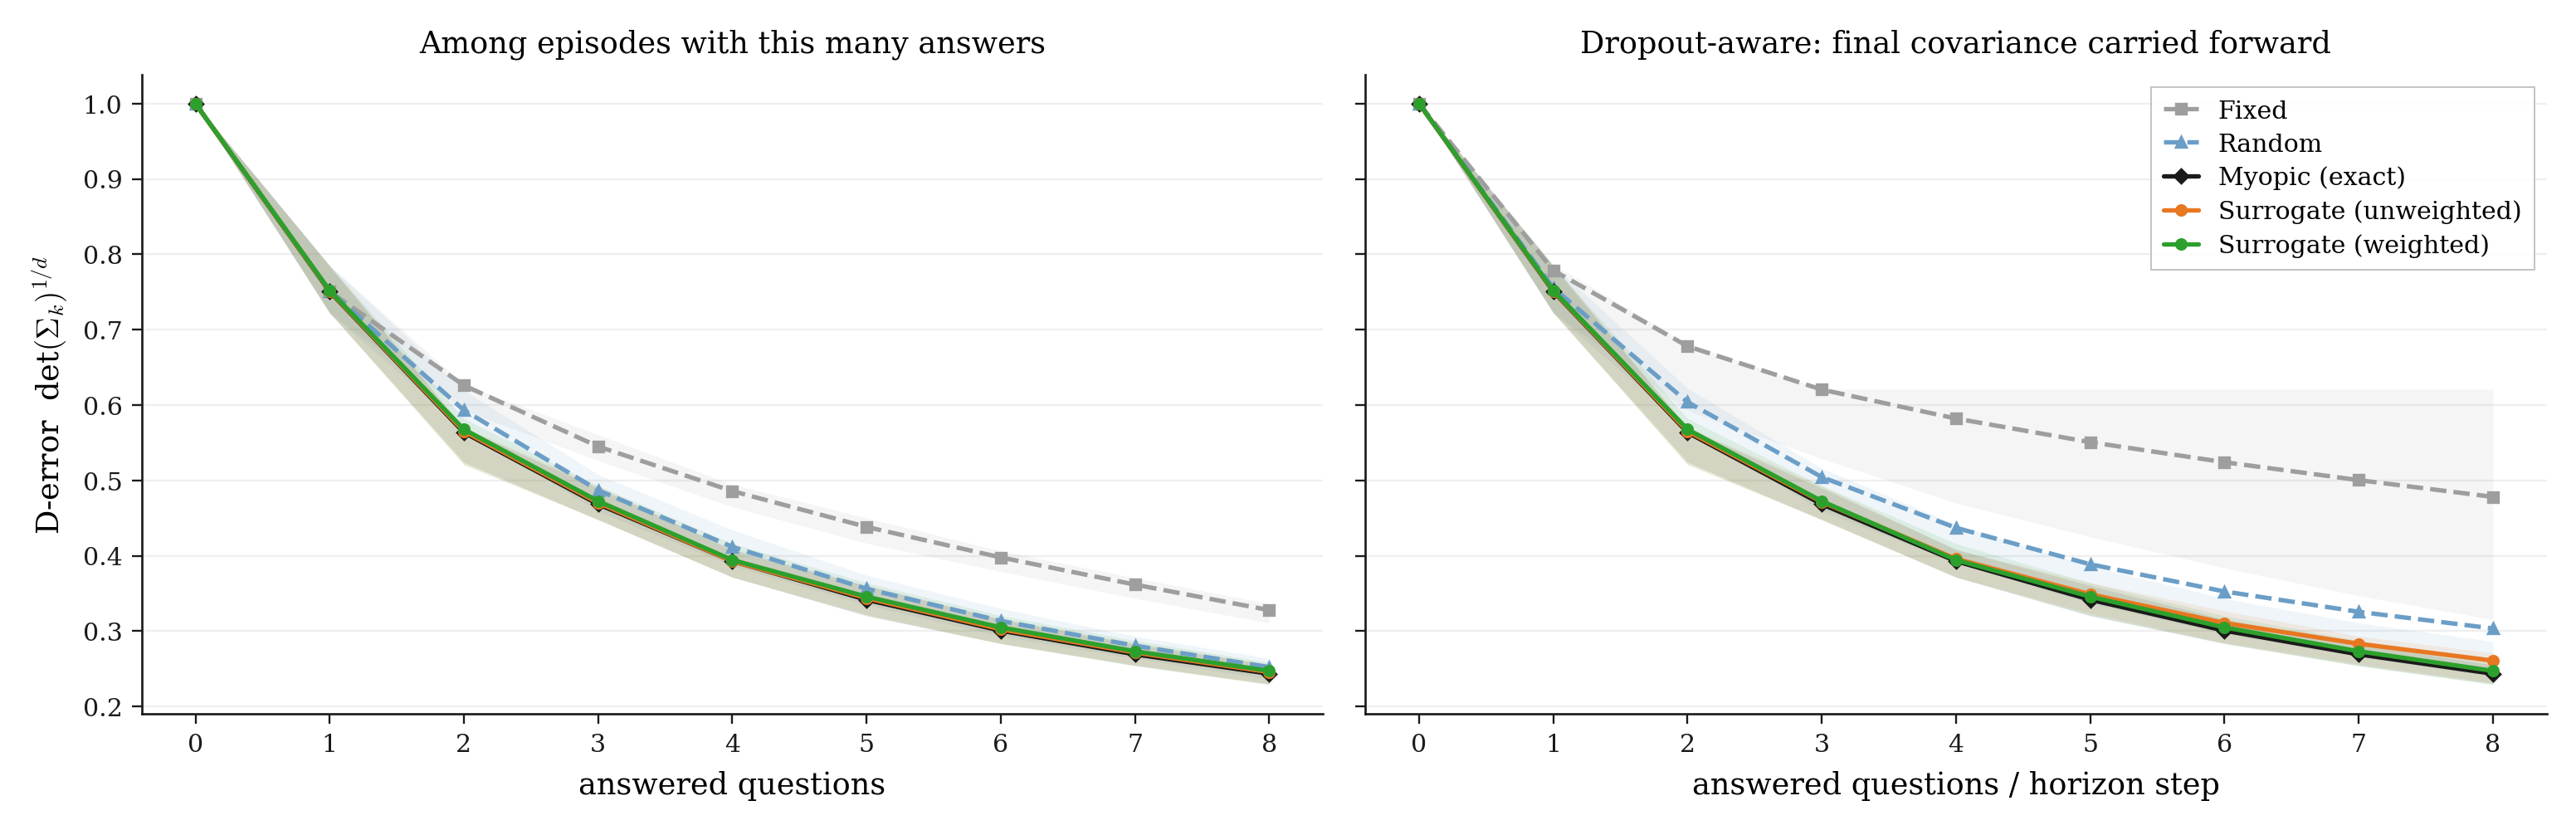

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), sharey=True)

for policy in POLICIES:
    style = POLICY_STYLE.get(policy, {})
    label = style.get("label", policy)
    color = style.get("color", None)
    linestyle = style.get("ls", "-")
    marker = style.get("marker", "o")

    for ax, mode in zip(axes, ["available", "carried"]):
        curve = curves[policy][mode]
        ax.plot(
            curve["answered"],
            curve["mean"],
            color=color,
            linestyle=linestyle,
            marker=marker,
            markersize=3.5,
            linewidth=1.6,
            label=label,
        )
        ax.fill_between(
            curve["answered"],
            curve["q25"],
            curve["q75"],
            color=color,
            alpha=0.10,
            linewidth=0,
        )

axes[0].set_title("Among episodes with this many answers")
axes[0].set_xlabel("answered questions")
axes[0].set_ylabel(r"D-error  det$(\Sigma_k)^{1/d}$")
style_ax(axes[0], grid_axis="y")

axes[1].set_title("Dropout-aware: final covariance carried forward")
axes[1].set_xlabel("answered questions / horizon step")
style_ax(axes[1], grid_axis="y")
axes[1].legend(loc="upper right", frameon=True)

plt.tight_layout()
plt.show()


## Sample Size Behind The Conditional Curve

When dropout is active, the conditional curve at later answered-question counts is computed from fewer episodes. This diagnostic shows how many users contribute to each point in the left panel.


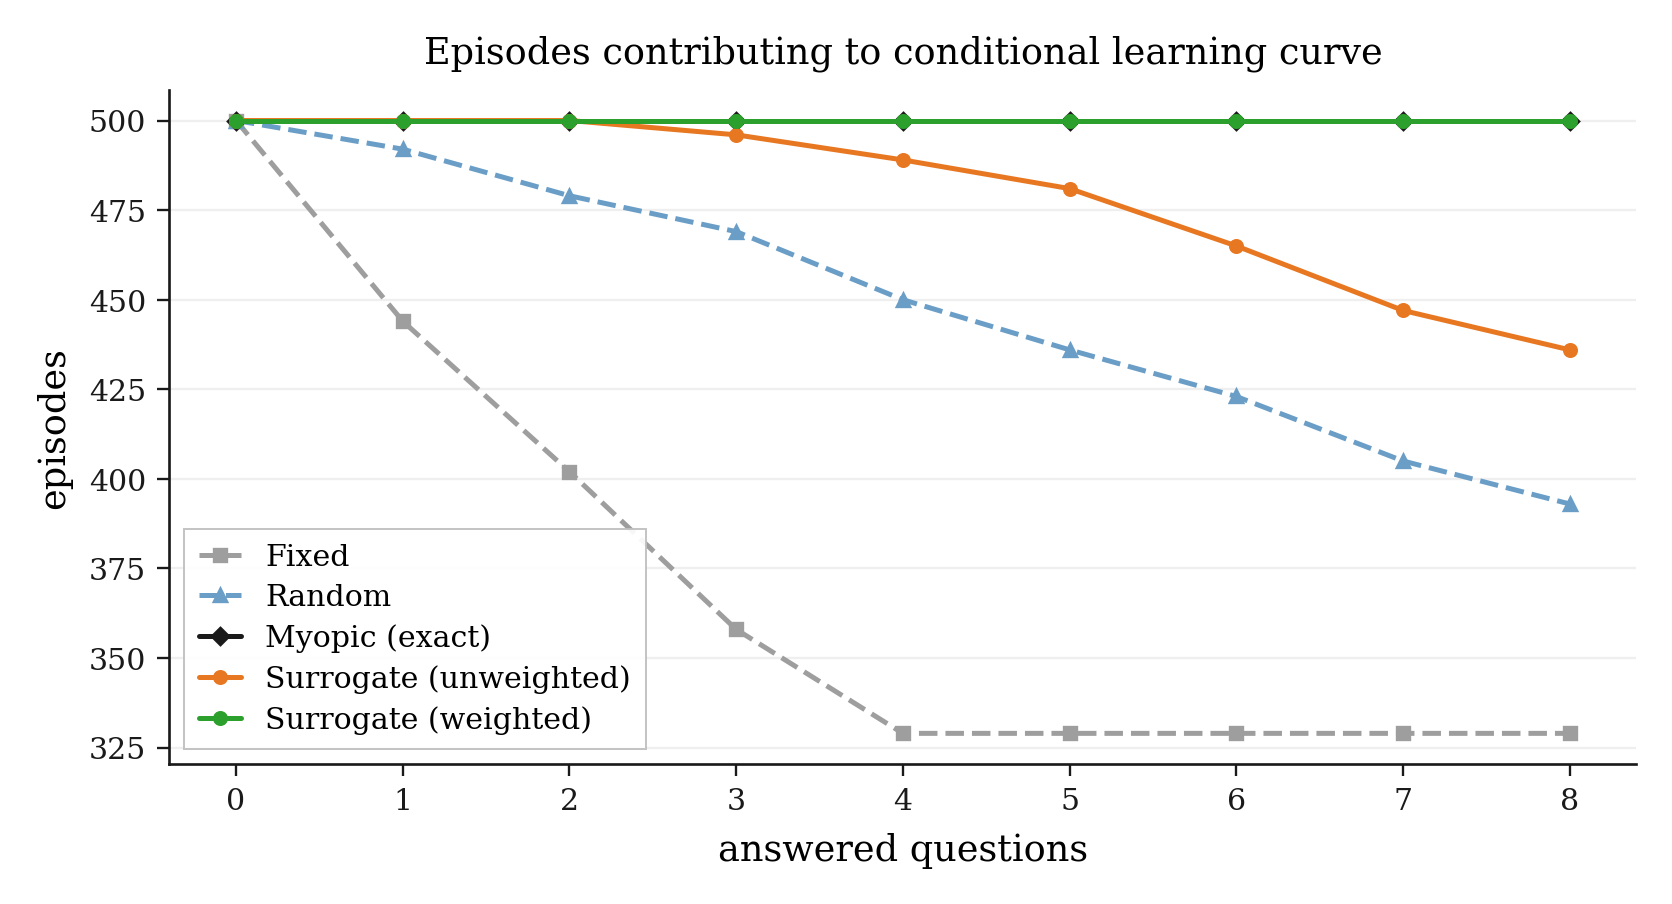

In [26]:
fig, ax = plt.subplots(figsize=(7, 3.8))

for policy in POLICIES:
    style = POLICY_STYLE.get(policy, {})
    curve = curves[policy]["available"]
    ax.plot(
        curve["answered"],
        curve["n"],
        color=style.get("color", None),
        linestyle=style.get("ls", "-"),
        marker=style.get("marker", "o"),
        markersize=3.5,
        linewidth=1.5,
        label=style.get("label", policy),
    )

ax.set_title("Episodes contributing to conditional learning curve")
ax.set_xlabel("answered questions")
ax.set_ylabel("episodes")
style_ax(ax, grid_axis="y")
ax.legend(loc="lower left", frameon=True)
plt.tight_layout()
plt.show()


## Curve Data

Use this table if you want to export or annotate exact curve values.


In [ ]:
curve_rows = []
for policy in POLICIES:
    for mode, curve in curves[policy].items():
        for row in curve.to_dict("records"):
            curve_rows.append({
                "policy": policy,
                "mode": mode,
                **row,
            })

curve_df = pd.DataFrame(curve_rows)


,policy,mode,answered,mean,median,q25,q75,n
0,fixed,available,0,1.000000,1.000000,1.000000,1.000000,500
1,fixed,available,1,0.750734,0.722530,0.721477,0.784834,444
2,fixed,available,2,0.626020,0.622785,0.592870,0.627232,402
3,fixed,available,3,0.544951,0.534388,0.526163,0.560564,358
4,fixed,available,4,0.485791,0.478813,0.464874,0.494562,329
5,fixed,available,5,0.438197,0.429184,0.416540,0.449973,329
6,fixed,available,6,0.397727,0.387714,0.379031,0.406558,329
7,fixed,available,7,0.361621,0.352671,0.343300,0.370565,329
8,fixed,available,8,0.327788,0.319152,0.310674,0.336312,329
9,fixed,carried,0,1.000000,1.000000,1.000000,1.000000,500
